<a href="https://colab.research.google.com/github/Albedofan69420/FASHION-MNIST/blob/main/FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.- Introducción

Nuestra problemática principal se centra en la poseción de 60.000 imágenes de prendas diferentes en escala de grises sin categorizar. Si bien se comprende la existencia de diez clases diferentes para cada una (camisetas, pantalones, zapatillas, entre otros.).

**Objetivo principal:**

Desarrollar un modelo capaz de aprender patrones a partir de los datos y clasificar correctamente nuevas imágenes. Para lograrlo, se realiza un proceso completo que abarca desde la carga y preprocesamiento de los datos hasta la evaluación del modelo utilziando diversas métricas de desempeño.

En una primera etapa, se preparan los datos para su uso en redes neuroales, transformando las imágenes a vectores y normalizando sus valores para mejorar la eficiencia del entrenamiento. Posteriormente, se construye una red neuronal multicapa, definiendo su arquitectura, funciones de activación y función de pérdida.

A continuación, se entrenará el modelo variando distintos hiperparámetros claves, tales como el número de épocas, tamaño de batch y optimizadores. Se realizará una comparación entre distintos algoritmos de optimización, incluyendo *SGD, Adam, RMSprop*, así como variantes como *Momentum y Nesterov*, con el fin de identificar cuál ofrece un mejor desempeño.

Además, se incorporarán técnicas de regularización como *Dropout y Early Stopping*, con el objetivo de reducir el sobreajuste(*overfitting*) y mejorar la capacidad de generalización del modelo.

Finalmente, el desempeño del modelo será evaluado mediante métricas como *accuracy, precision, recall y F1-score*, permitiendo analizar de manera integral la calidad de las predicciones. A partir de estos resultados, se jusatificarán las decisiones tomadas durante el desarrollo y se seleccionará la mejor configuración del modelo, mostrando ejemplos visuales de cómo responde el mejor modelo obtenido.

#2.- Carga y procesamiento de datos



In [ ]:
# Importación de librerias necesarias para el desarrollo
from tensorflow import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


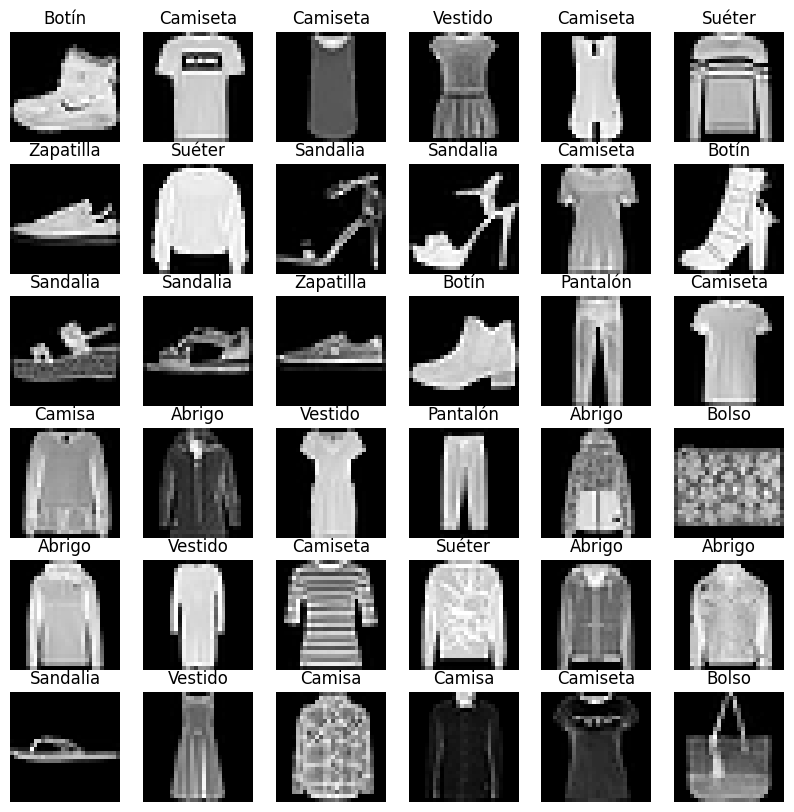

In [ ]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

In [ ]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

Y_train = y_train
Y_test = y_test

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000,)


En la carga y pre-procresamiento de datos se hicieron los elementos descritos a continuación:

*   Se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo, escalando los valores para evitar números grandes.
*   Las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.
*   Las etiquetas se representaron como números enteros del 0 al 9 a través de la técnica de one hot encoding, donde cada número corresponde a una clase o prenda.
Para que el modelo pueda trabajar con este formato, se utilizó la función de pérdida sparse categorical crossentropy, que permite entrenar directamente con etiquetas numéricas sin necesidad de codificación adicional.

#3.- Definición del modelo

In [ ]:
# setamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = 10 # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N,  activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
modelA = crear_modelo()
modelA.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

El modelo implementado corresponde a una red neuronal multicapa (MLP) compuesta por tres capas ocultas con 512, 256 y 256 neuronas respectivamente, y una capa de salida de 10 neuronas.

El modelo presenta un total de 601.610 parámetros entrenables, lo que indica una alta capacidad de aprendizaje. Esta gran cantidad de parámetros permite al modelo capturar patrones complejos presentes en las imágenes del dataset.

Sin embargo, esta alta capacidad también implica un mayor riesgo de sobreajuste, ya que el modelo puede llegar a memorizar los datos de entrenamiento en lugar de generalizar correctamente.

Por esta razón, este modelo será utilizado como base para posteriormente aplicar técnicas de regularización que permitan mejorar su desempeño en datos no vistos.

#4.- Entrenamiento y ajuste de hiperparámetros

##1°er entrenamiento:

Se decidió entrenar el modelo de forma inicial con **20 épocas** y un **batch size de 32**, debido a su uso como configuración estandar, además de servir como primer vistazo al comportamiento del modelo sin incurrir en tiempos de entrenamiento exhaustos. Por otro lado, se seleccionó un 20% del entrenamiento para la validación basándonos en las buenas prácticas de separación de 80/20, sin utilizar menos ni más al considerar el tamaño moderado del dataset y el equilibrio en la cantidad de datos necesarios para validar la capacidad de generalización del modelo.

In [ ]:
# ===== EXPERIMENTO CONTROLADO ENTRENAMIENTO A =====
np.random.seed(30)
tf.random.set_seed(30)

modelA = crear_modelo()

historyA = modelA.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8203 - loss: 0.4929 - val_accuracy: 0.8539 - val_loss: 0.3994
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8634 - loss: 0.3712 - val_accuracy: 0.8658 - val_loss: 0.3716
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8766 - loss: 0.3318 - val_accuracy: 0.8655 - val_loss: 0.3789
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8855 - loss: 0.3060 - val_accuracy: 0.8798 - val_loss: 0.3337
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8924 - loss: 0.2865 - val_accuracy: 0.8798 - val_loss: 0.3356
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8997 - loss: 0.2667 - val_accuracy: 0.8830 - val_loss: 0.3484
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9040 - loss: 0.2560 - val_accuracy: 0.8803 - val_loss: 0.3547
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9071 - loss: 0.2450 - 

###Evaluación y visualización del primer entrenamiento

In [ ]:
# Resultados modelA:

print(f"Train accuracy \u2248 {historyA.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyA.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 94.0%
Val accuracy ≈ 88.7%


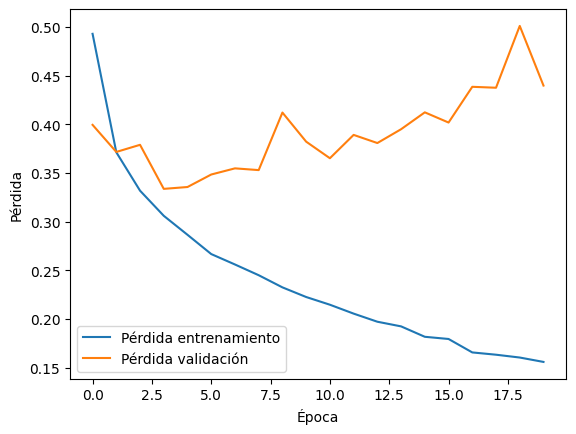

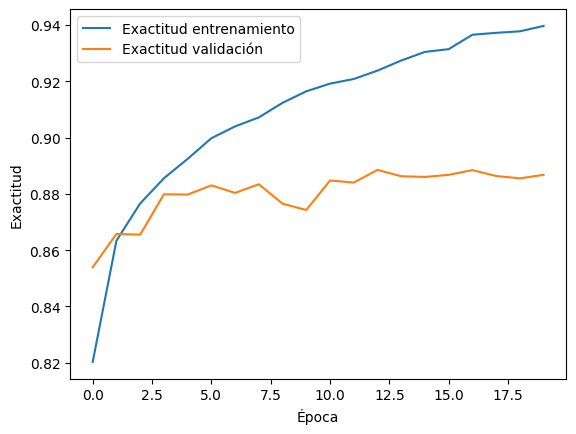

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(historyA.history['loss'], label='Pérdida entrenamiento')
plt.plot(historyA.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(historyA.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(historyA.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***

*   La **pérdida de entrenamiento** disminuye de forma constante a lo largo de las épocas, indicando que el modelo está aprendiendo correctamente los patrones de datos de entrenamiento.

*   Por otro lado, la **pérdida de validación** disminuye inicialmente, pero luego comienza a aumentar progresivamente, lo que es una señal clara de **sobreajuste**.

***Exactitud***

*   El **accuracy de entrenamiento** aumentaa de forma sostenida, alcanzando valores cercanos al 95%. Esto indica que el modelo se ajusta muy bien a los datos que ha visto.
*   El **accuracy de validación** mejora al inicio pero luego se estanca e inluso presenta pequeñas fluctuaciones. Este becha creciente entrenamiento y validación refuerza la presencia de **overfitting**.

##2°do entrenamiento

Ante la evidencia del entrenamiento anterior, se tomó la decisión de aumentar los hiperparámetros por **30 épocas**, lo que permite analizar cómo del modelo se comporta bajo una configuración más intensiva.

In [ ]:
# ===== EXPERIMENTO CONTROLADO ENTRENAMIENTO B =====
np.random.seed(30)
tf.random.set_seed(30)

modelB = crear_modelo()

historyB = modelB.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8197 - loss: 0.4970 - val_accuracy: 0.8544 - val_loss: 0.4034
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8628 - loss: 0.3710 - val_accuracy: 0.8631 - val_loss: 0.3809
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8755 - loss: 0.3344 - val_accuracy: 0.8773 - val_loss: 0.3390
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8870 - loss: 0.3070 - val_accuracy: 0.8760 - val_loss: 0.3418
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8928 - loss: 0.2859 - val_accuracy: 0.8780 - val_loss: 0.3497
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8988 - loss: 0.2694 - val_accuracy: 0.8749 - val_loss: 0.3837
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9026 - loss: 0.2562 - val_accuracy: 0.8818 - val_loss: 0.3578
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9068 - loss: 0.2434 - 

###Evaluación y visualización del segundo entrenamiento

In [ ]:
# Resultados modelB:

print(f"Train accuracy \u2248 {historyB.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyB.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 95.2%
Val accuracy ≈ 88.0%


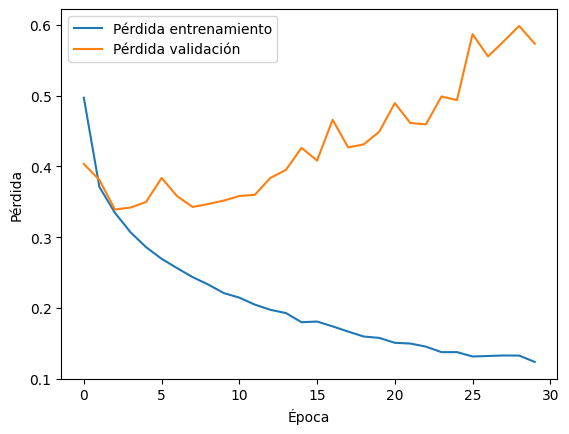

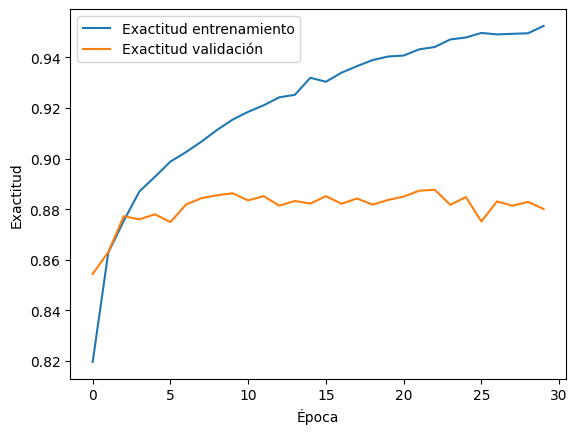

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(historyB.history['loss'], label='Pérdida entrenamiento')
plt.plot(historyB.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(historyB.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(historyB.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***
* La **pérdida de entrenamiento** disminuye de forma continua, alcanzando valores muy bajos, lo que indica que el modelo está aprendiendo bien.
* La **pérdida de validación** disminuye levemente al inicio. Luego aumenta de forma sostenida y más pronunciada que en el Modelo A, lo que indica que el **overfitting** aquí es más agresivo y evidente.

***Exactitud***
* El **accuracy de entrenamiento** sigue aumentando hasta un 97% o 98%, lo que demuestra que el modelo está **memorizando** los datos.
* El **accuracy de validación** no mejora pese al aumento de épocas.

##3°er entrenamiento

Como ya se visualizó la ocurrencia al aumentar la cantidad de épocas, esta vez se decidió utilizar 10 para analizar una configuración más ligera.

In [ ]:
# ===== EXPERIMENTO CONTROLADO ENTRENAMIENTO C =====
np.random.seed(30)
tf.random.set_seed(30)

modelC = crear_modelo()

historyC = modelC.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8217 - loss: 0.4951 - val_accuracy: 0.8526 - val_loss: 0.3992
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.3728 - val_accuracy: 0.8675 - val_loss: 0.3658
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8762 - loss: 0.3333 - val_accuracy: 0.8775 - val_loss: 0.3464
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8873 - loss: 0.3048 - val_accuracy: 0.8741 - val_loss: 0.3485
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8914 - loss: 0.2877 - val_accuracy: 0.8702 - val_loss: 0.3807
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8985 - loss: 0.2689 - val_accuracy: 0.8789 - val_loss: 0.3478
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9037 - loss: 0.2526 - val_accuracy: 0.8871 - val_loss: 0.3285
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9077 - loss: 0.2408 - 

###Evaluación y visualización del tercer entrenamiento

In [ ]:
# Resultados modelC:

print(f"Train accuracy \u2248 {historyC.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyC.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 91.5%
Val accuracy ≈ 88.4%


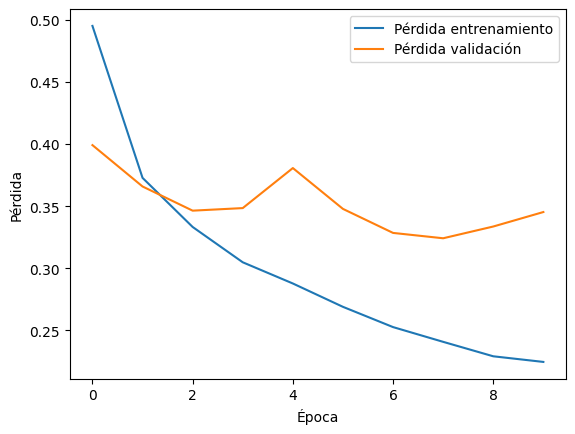

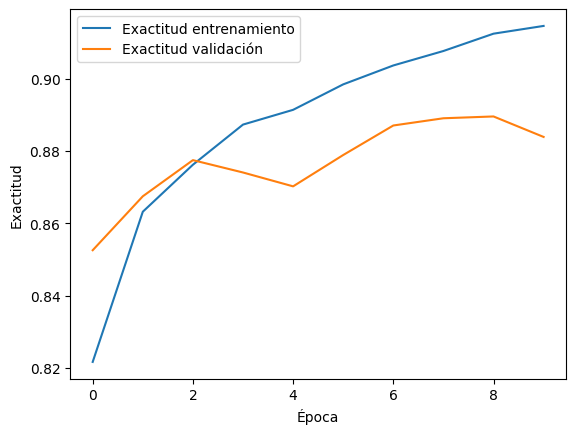

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(historyC.history['loss'], label='Pérdida entrenamiento')
plt.plot(historyC.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(historyC.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(historyC.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***
* La **perdida de entrenamiento** disminuye, pero de forma lenta.
* La **perdida de validación**, a pesar de disminuir al inicio, incrementa repentinamente y genera una curva hacia arriba.

***Exactitud***
* El **accuracy de entrenamiento** demuestra un aprendizaje del 92%, ajustandose a los datos.
* El **accuracy de validación** mejora inicialmente hasta disminuir, creando una curva con el mismo proceso, indicando su incapacidad para aprender de los patrones.

##4°to entrenamiento

Esta vez se decidió aumentar **batch size** a **64** y analizar si es que genera cambios relevantes en el aprendizaje del modelo.

In [ ]:
# ===== EXPERIMENTO CONTROLADO ENTRENAMIENTO D =====
np.random.seed(30)
tf.random.set_seed(30)

modelD = crear_modelo()

historyD = modelD.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8005 - loss: 0.5416 - val_accuracy: 0.8450 - val_loss: 0.4160
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8597 - loss: 0.3870 - val_accuracy: 0.8687 - val_loss: 0.3678
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8739 - loss: 0.3442 - val_accuracy: 0.8778 - val_loss: 0.3600
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8826 - loss: 0.3203 - val_accuracy: 0.8770 - val_loss: 0.3845
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8886 - loss: 0.3046 - val_accuracy: 0.8707 - val_loss: 0.4136
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8921 - loss: 0.2958 - val_accuracy: 0.8798 - val_loss: 0.3914
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8959 - loss: 0.2859 - val_accuracy: 0.8791 - val_loss: 0.4129
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8973 - loss: 0.2805 - val_accuracy: 0.

###Evaluación y visualización del cuarto entrenamiento

In [ ]:
# Resultados modelD:

print(f"Train accuracy \u2248 {historyD.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyD.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 92.5%
Val accuracy ≈ 88.6%


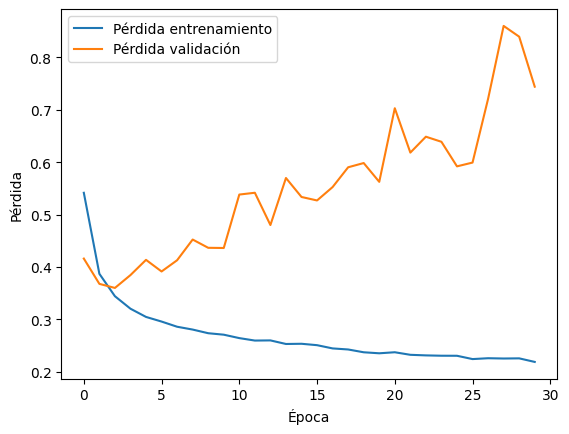

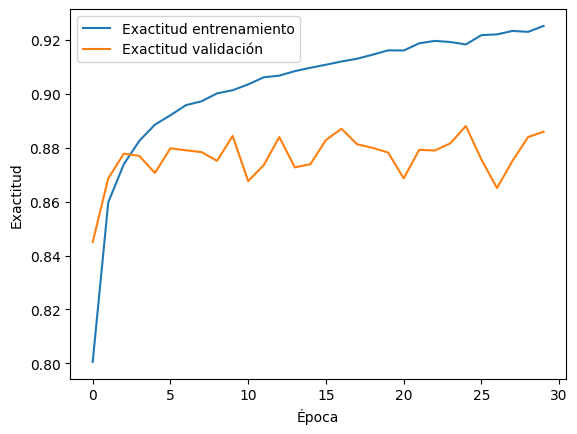

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(historyD.history['loss'], label='Pérdida entrenamiento')
plt.plot(historyD.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(historyD.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(historyD.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***
* La **pérdida de entrenamiento** baja de forma continua, pero de forma tardia.
* La **pérdida de validación** no disminuye y se mantiene, demostrando dificultad en el aprendizaje.

***Exactitud***
* El **accuracy de entrenamiento** aumenta hasta el 92%, ajustandose bien a los datos.
* El **accuracy de validación** se mantiene en un 88%, con fluctuaciones que aumentan cerca del 90%.


##Conclusión del entrenamiento

A comparación de los demás modelos, se es capaz de comprender que el **modelD** mantuvo un equilibrio de aprendizaje, perdida y exactitud en comparación de los modelos de los otros entrenamientos, pero con la misma **incapacidad de aprendizaje** y con tendencias al **overfitting.**

Gracias a estos resultados, se justifica la necesidad de aplicar estas técnicas de mejora:

> **Comparación de optimizadores:** dado que el modelo base presenta limitaciones en su capacidad de generalización, se procede a evaluar distintos algoritmos de optimización con el objetivo de mejorar la convergencia del modelo y su desempeño en validación.

> **Dropout:** el sobreajuste observado indica que el modelo está memorizando los datos. Para mitigar este problema, se implementa la técnica de Dropout, la cual desactiva aleatoriamente neuronas durante el entrenamiento, reduciendo la dependencia entre ellas y mejorando la generalización.

>**Early Stopping:** dado que el mejor rendimiento ocurre en las primeras épocas, se incorpora Early Stopping en conjunto con ModelCheckpoint, una técnica que detiene automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar, evitando así el sobreentrenamiento.

#5.- Comparación de optimizadores

En esta parte, se evaluarán cómo distintos optimizadores afectan el aprendizaje del modelo MLP.

Se probaran:

- **SGD.**
- **SGD + Momentum.**
- **SGD + Nesterov.**
- **Adam.**
- **RMSprop.**

In [ ]:
# Semillas para reproducibilidad
np.random.seed(30)
tf.random.set_seed(30)

# Definición de optimizadores
optimizadores = {
    'SGD': keras.optimizers.SGD(),
    'SGD + Momentum': keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': keras.optimizers.Adam(),
    'RMSprop': keras.optimizers.RMSprop()
}

#definición del modelo base
def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

##Entrenamiento con distintos optimizadores

Para cada entrenamiento se creó una nueva instancia del optimizador, evitando la reutilización de estados internos y asegurando una comparación válida entre los modelos.

In [ ]:
histories = {}
resultados = []

optimizadores = {
    'SGD': lambda: keras.optimizers.SGD(),
    'SGD + Momentum': lambda: keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': lambda: keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': lambda: keras.optimizers.Adam(),
    'RMSprop': lambda: keras.optimizers.RMSprop()
}

for nombre, crear_opt in optimizadores.items():

    model = crear_modelo()

    optimizer = crear_opt()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    histories[nombre] = history

    resultados.append({
        "Optimizador": nombre,
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1]
    })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7210 - loss: 0.8828 - val_accuracy: 0.7970 - val_loss: 0.5949
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8154 - loss: 0.5395 - val_accuracy: 0.8250 - val_loss: 0.5082
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8341 - loss: 0.4802 - val_accuracy: 0.8373 - val_loss: 0.4705
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8457 - loss: 0.4484 - val_accuracy: 0.8446 - val_loss: 0.4476
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8525 - loss: 0.4263 - val_accuracy: 0.8518 - val_loss: 0.4296
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8589 - loss: 0.4088 - val_accuracy: 0.8557 - val_loss: 0.4153
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8634 - loss: 0.3946 - val_accuracy: 0.8583 - val_loss: 0.4049
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8676 - loss: 0.3825 - val_accuracy: 0.

##Comparación de los optimizadores

In [ ]:
df_results_opt = pd.DataFrame(resultados)

print("Resultados finales:")
print(df_results_opt)

Resultados finales:
      Optimizador  Train Accuracy  Val Accuracy
0             SGD        0.912417      0.885500
1  SGD + Momentum        0.958458      0.875167
2  SGD + Nesterov        0.964000      0.872500
3            Adam        0.957458      0.877333
4         RMSprop        0.923292      0.881583


In [ ]:
mejor_opt = df_results_opt.sort_values(by="Val Accuracy", ascending=False).iloc[0]["Optimizador"]

print("Mejor optimizador:", mejor_opt)

Mejor optimizador: SGD


##Gráfico comparativo entre optimizadores:

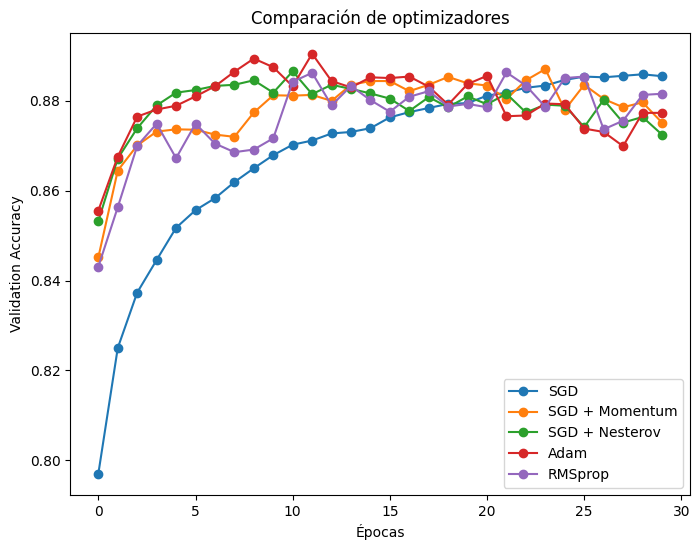

In [ ]:
plt.figure(figsize=(8,6))

for opt in histories:
    plt.plot(histories[opt].history['val_accuracy'], marker='o', label=opt)

plt.title("Comparación de optimizadores")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

**Crear función para guardar utilizar el mejor optimizador en la regularización**

In [ ]:
def obtener_optimizador(nombre):

    if nombre == 'SGD':
        return keras.optimizers.SGD()

    elif nombre == 'SGD + Momentum':
        return keras.optimizers.SGD(momentum=0.9)

    elif nombre == 'SGD + Nesterov':
        return keras.optimizers.SGD(momentum=0.9, nesterov=True)

    elif nombre == 'Adam':
        return keras.optimizers.Adam()

    elif nombre == 'RMSprop':
        return keras.optimizers.RMSprop()

    else:
        raise ValueError("Optimizador no reconocido")

##Resultados

A partir de los resultados obtenidos, se puede observar lo siguiente:


In [ ]:
print(f"El mejor optimizador fue {mejor_opt} con {df_results_opt['Val Accuracy'].max()*100:.2f}% de accuracy")

El mejor optimizador fue SGD con 88.55% de accuracy


#6.- Regularización

##Dropout

In [ ]:
# Seteamos los seed para números random

np.random.seed(30)
tf.random.set_seed(30)

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.summary()

model_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=obtener_optimizador(mejor_opt),
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_data=(X_test,Y_test)
       )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6024 - loss: 1.1096 - val_accuracy: 0.7515 - val_loss: 0.6731
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7569 - loss: 0.6962 - val_accuracy: 0.7952 - val_loss: 0.5652
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7913 - loss: 0.5985 - val_accuracy: 0.8132 - val_loss: 0.5121
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8104 - loss: 0.5418 - val_accuracy: 0.8240 - val_loss: 0.4804
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8209 - loss: 0.5077 - val_accuracy: 0.8310 - val_loss: 0.4597
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8316 - loss: 0.4814 - val_accuracy: 0.8365 - val_loss: 0.4474
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8358 - loss: 0.4635 - val_accuracy: 0.8424 - val_loss: 0.4336
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8415 - loss: 0.4473 - val_accuracy: 0.

###Evaluación y visualización

In [ ]:
# Resultados model con Dropout

print(f"Train accuracy \u2248 {history_dropout.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_dropout.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 88.8%
Val accuracy ≈ 87.9%


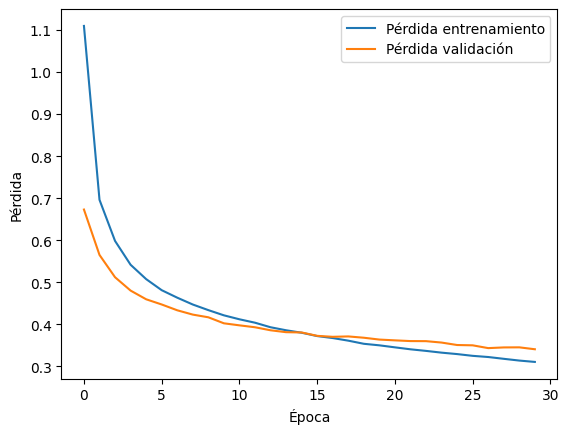

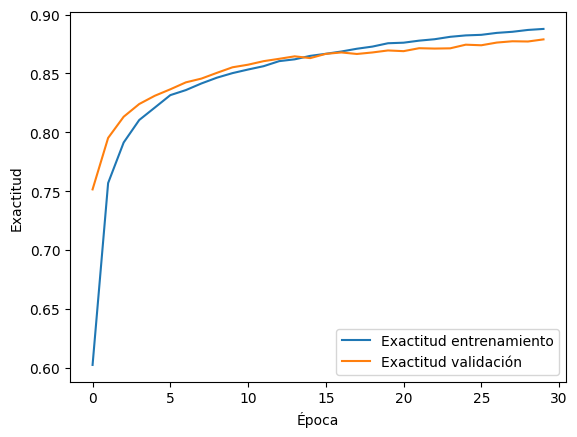

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_dropout.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_dropout.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(history_dropout.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(history_dropout.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

##EarlyStopping

In [ ]:
# Creación del callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'mejor_modelo.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
# Creación del modelo

def crear_modelo_final():

    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(10, activation='softmax')
    ])

    optimizer_final = obtener_optimizador(mejor_opt)

    model.compile(
        optimizer=optimizer_final,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Entrenamiento con Early Stopping

model_stopping = crear_modelo_final()

history_stopping = model_stopping.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
745/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5208 - loss: 1.4286
Epoch 1: val_loss improved from None to 0.61943, saving model to mejor_modelo.h5



Epoch 1: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6451 - loss: 1.0444 - val_accuracy: 0.7848 - val_loss: 0.6194
Epoch 2/50
731/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7635 - loss: 0.6771
Epoch 2: val_loss improved from 0.61943 to 0.51928, saving model to mejor_modelo.h5



Epoch 2: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7750 - loss: 0.6461 - val_accuracy: 0.8224 - val_loss: 0.5193
Epoch 3/50
731/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8009 - loss: 0.5766
Epoch 3: val_loss improved from 0.51928 to 0.47767, saving model to mejor_modelo.h5



Epoch 3: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8053 - loss: 0.5624 - val_accuracy: 0.8341 - val_loss: 0.4777
Epoch 4/50
743/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8168 - loss: 0.5273
Epoch 4: val_loss improved from 0.47767 to 0.45139, saving model to mejor_modelo.h5



Epoch 4: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8195 - loss: 0.5157 - val_accuracy: 0.8420 - val_loss: 0.4514
Epoch 5/50
732/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4912
Epoch 5: val_loss improved from 0.45139 to 0.43029, saving model to mejor_modelo.h5


...


Epoch 36: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9040 - loss: 0.2696 - val_accuracy: 0.8886 - val_loss: 0.3057
Epoch 37/50
745/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9027 - loss: 0.2716
Epoch 37: val_loss improved from 0.30570 to 0.30483, saving model to mejor_modelo.h5



Epoch 37: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9036 - loss: 0.2679 - val_accuracy: 0.8897 - val_loss: 0.3048
Epoch 38/50
733/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9032 - loss: 0.2708
Epoch 38: val_loss did not improve from 0.30483
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9045 - loss: 0.2660 - val_accuracy: 0.8890 - val_loss: 0.3050
Epoch 39/50
735/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9017 - loss: 0.2674
Epoch 39: val_loss improved from 0.30483 to 0.30436, saving model to mejor_modelo.h5



Epoch 39: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9044 - loss: 0.2619 - val_accuracy: 0.8908 - val_loss: 0.3044
Epoch 40/50
745/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9054 - loss: 0.2618
Epoch 40: val_loss improved from 0.30436 to 0.30230, saving model to mejor_modelo.h5



Epoch 40: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9057 - loss: 0.2591 - val_accuracy: 0.8896 - val_loss: 0.3023
Epoch 41/50
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9056 - loss: 0.2620
Epoch 41: val_loss improved from 0.30230 to 0.30060, saving model to mejor_modelo.h5



Epoch 41: finished saving model to mejor_modelo.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9073 - loss: 0.2570 - val_accuracy: 0.8915 - val_loss: 0.3006
Epoch 42/50
729/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9076 - loss: 0.2582
Epoch 42: val_loss did not improve from 0.30060
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9084 - loss: 0.2543 - val_accuracy: 0.8906 - val_loss: 0.3014
Epoch 43/50
738/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9082 - loss: 0.2549
Epoch 43: val_loss did not improve from 0.30060
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9097 - loss: 0.2518 - val_accuracy: 0.8910 - val_loss: 0.3008
Epoch 44/50
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9098 - loss: 0.2518
Epoch 44: val_loss did not improve from 0.30060
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9113 - loss: 0.2460 - val_accuracy: 0.8913 - val_loss: 0.3016


###Evaluación y visualización

In [ ]:
# Resultados model con Early Stopping

print(f"Train accuracy \u2248 {history_stopping.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_stopping.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 91.1%
Val accuracy ≈ 89.1%


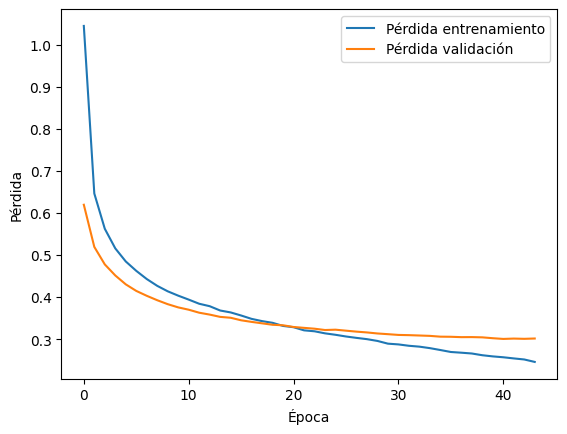

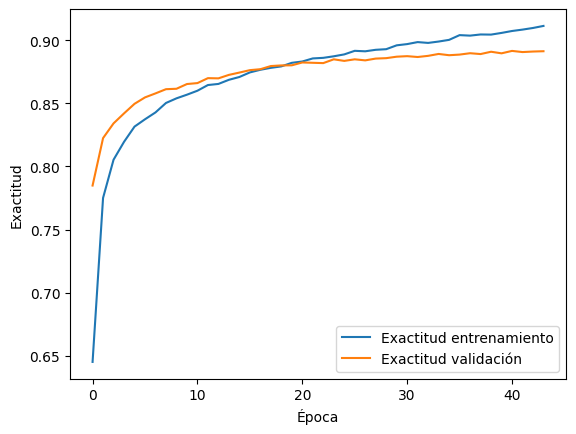

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_stopping.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_stopping.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(history_stopping.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(history_stopping.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()



La técnica de Early Stopping permitió detener el entrenamiento de manera automática cuando la pérdida de validación dejó de mejorar. Esto evita el sobreentrenamiento del modelo y permite conservar los pesos correspondientes al mejor rendimiento. Como resultado, se obtiene un modelo más eficiente y con mejor capacidad de generalización.

Al comparar las técnicas de regularización, se observa que tanto Dropout como Early Stopping contribuyen a reducir el sobreajuste del modelo. Sin embargo, la combinación de ambas técnicas permite obtener un mejor equilibrio entre aprendizaje y generalización, logrando un modelo más robusto, apoyado en cojunto por el uso de ModelCheckpoint. Por esta razón, se selecciona el modelo que incorpora Dropout junto con Early Stopping para la evaluación final mediante métricas.

##Creación de modelo con ambas regularizaciones

In [ ]:
#Se utiliza función para crear modelo final

model_final = crear_modelo_final()

history_final = model_final.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4400 - loss: 1.6673
Epoch 1: val_loss did not improve from 0.30060
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5688 - loss: 1.2749 - val_accuracy: 0.7270 - val_loss: 0.7511
Epoch 2/50
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7098 - loss: 0.8260
Epoch 2: val_loss did not improve from 0.30060
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7229 - loss: 0.7860 - val_accuracy: 0.7852 - val_loss: 0.6215
Epoch 3/50
361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7579 - loss: 0.7011
Epoch 3: val_loss did not improve from 0.30060
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7648 - loss: 0.6791 - val_accuracy: 0.8106 - val_loss: 0.5559


###Evaluación y visualización

In [ ]:
# Resultados model con Dropout y Early Stopping

print(f"Train accuracy \u2248 {history_final.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_final.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 76.5%
Val accuracy ≈ 81.1%


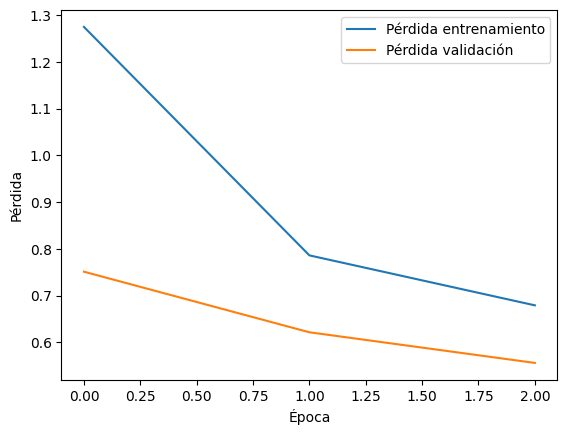

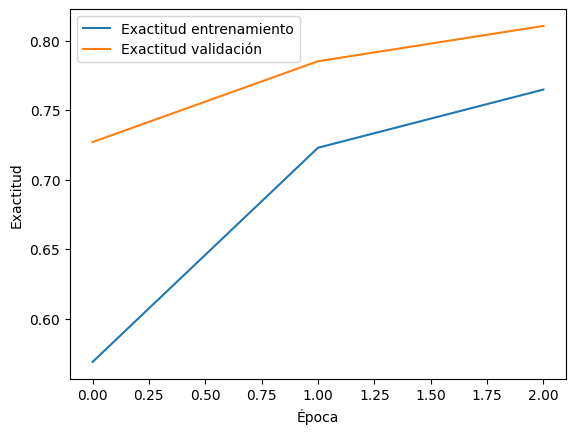

In [ ]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_final.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_final.history['val_loss'], label='Pérdida validación')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(history_final.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(history_final.history['val_accuracy'], label='Exactitud validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend()
plt.show()

##Conclusión

El modelo final, que incorpora Dropout y Early Stopping, presenta un accuracy de entrenamiento de 76.5% y un accuracy de validación de 81.1%. La diferencia entre ambas métricas indica que el modelo no presenta sobreajuste significativo y logra una adecuada generalización por sobre los datos. Además, el hecho de que el accuracy de validación sea superior se explica por el uso de Dropout y su capacidad para desactivar neuronas de forma aleatoria, la cual deja de realizar durante la etapa de validación, permitiendo así generar un modelo robusto y eficiente.



---



---



#7.- Métricas

Se evaluará el modelo final definido anteriormente con:
* Accuracy.
* Precision.
* Recall.
* F1-score.
* Matriz de confusión.

Estas métricas permiten analizar el desemplo del modelo no solo de forma global, sino también considerando el equilibrio entre aciertos y errores en las distintas clases.

##Preparar datos de prueba

In [ ]:
# Predicciones del modelo
y_pred_probs = model_final.predict(X_test)

# Convertimos probabilidades a clases
y_pred = y_pred_probs.argmax(axis=1)

# Aseguramos que y_test esté plano
y_true = Y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Comparación de valores reales vs los valores predichos

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7077
Precision: 0.7211
Recall:    0.7077
F1-score:  0.6937


In [ ]:
df_metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

df_metricas

,Métrica,Valor
0,Accuracy,0.707700
1,Precision,0.721147
2,Recall,0.707700
3,F1-score,0.693726


##Interpretación de resultados

1.   **Accuracy:** El modelo obtuvo un accuracy de 70.77%, lo que indica que clasifica correctamente la gran mayoría de las imágenes del conjunto de prueba. Este resultado refleja un alto nivel de desempeño considerando que se trata de una red neuronal del tipo MLP aplicada a un problema de clasificación de imágenes.

2.   **Precisión:** La precisión (precision) alcanzó un valor de 0.7211, lo que indica que cuando el modelo realiza una predicción, esta es correcta en la mayoría de los casos. Esto evidencia una baja tasa de falsos positivos.

3.   **Recall:** El recall obtenido fue de 0.7077, lo que indica que el modelo logra identificar correctamente la mayoría de las instancias reales de cada clase, manteniendo una baja tasa de falsos negativos.

4.   **F1-score** El F1-score alcanzó un valor de 0.6937, lo que demuestra un equilibrio adecuado entre precision y recall. Esto indica que el modelo presenta un desempeño consistente y balanceado en la clasificación de las distintas clases.


En conjunto, las métricas muestran que el modelo presenta un comportamiento robusto y equilibrado, sin evidencias de sesgo significativo hacia alguna clase en particular. La similitud entre precision, recall y F1-score confirman la estabilidad del modelo.

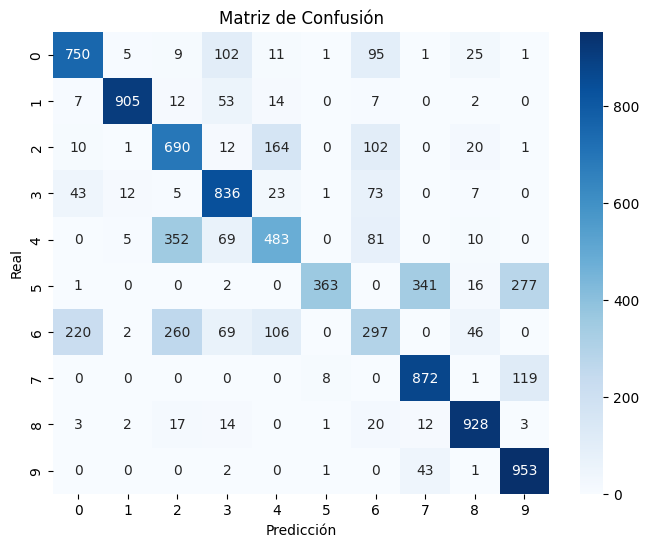

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

##Resultados matriz de confusión

#Ejemplo funcionamiento del modelo

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

prec_weighted = precision_score(y_test, y_pred, average='weighted')
rec_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision (macro):", prec_macro)
print("Recall (macro):", rec_macro)
print("F1-score (macro):", f1_macro)
print("Precision (weighted):", prec_weighted)
print("Recall (weighted):", rec_weighted)
print("F1-score (weighted):", f1_weighted)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.7077
Precision (macro): 0.7211471008530402
Recall (macro): 0.7077
F1-score (macro): 0.6937260341615495
Precision (weighted): 0.7211471008530403
Recall (weighted): 0.7077
F1-score (weighted): 0.6937260341615493
Balanced Accuracy: 0.7077


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74      1000
           1       0.97      0.91      0.94      1000
           2       0.51      0.69      0.59      1000
           3       0.72      0.84      0.77      1000
           4       0.60      0.48      0.54      1000
           5       0.97      0.36      0.53      1000
           6       0.44      0.30      0.35      1000
           7       0.69      0.87      0.77      1000
           8       0.88      0.93      0.90      1000
           9       0.70      0.95      0.81      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.69     10000
weighted avg       0.72      0.71      0.69     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


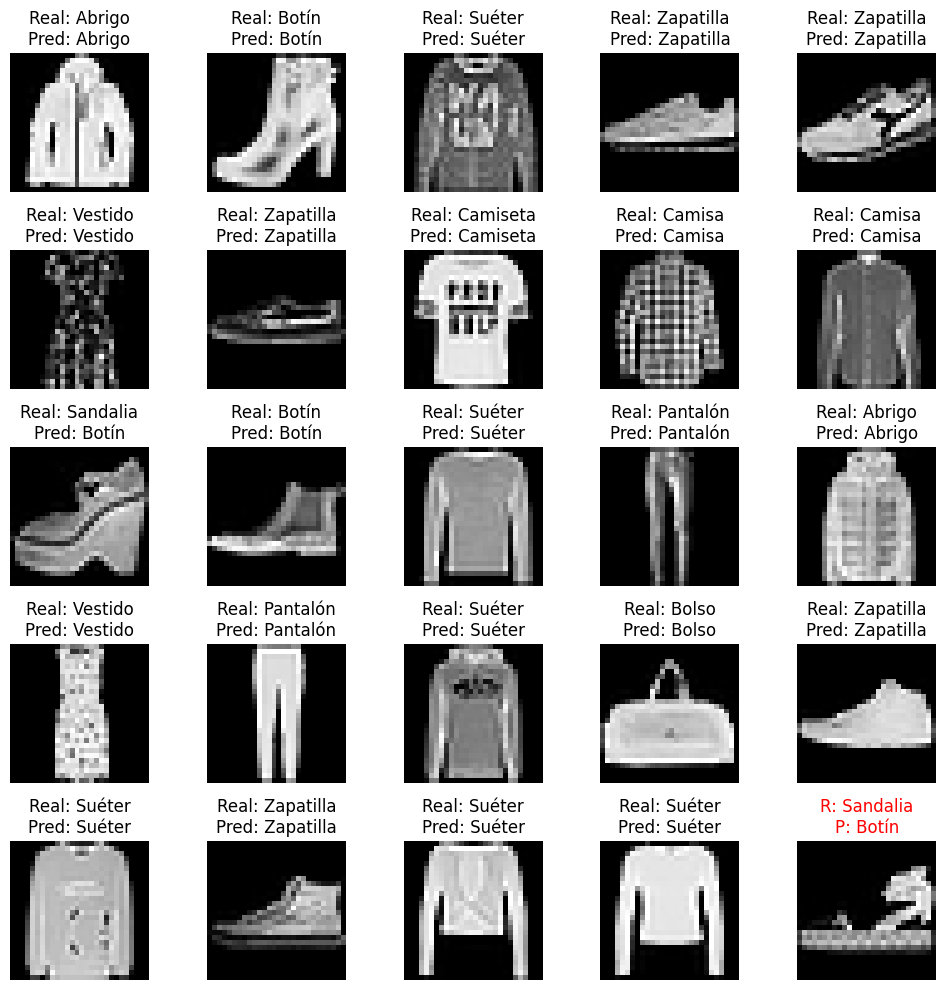

In [ ]:
# Elegimos 25 imágenes al azar
h, w = 5, 5
fig, axs = plt.subplots(h, w, figsize=(10,10))

for i in range(h):
    for j in range(w):
        idx = np.random.randint(len(X_test))

        img = X_test[idx].reshape(28,28)
        true_label = Y_test[idx]

        pred = model_final.predict(X_test[idx].reshape(1,784))
        pred_label = np.argmax(pred)

        axs[i,j].imshow(img, cmap='gray')
        axs[i,j].set_title(f"Real: {clases[true_label]}\nPred: {clases[pred_label]}")
        axs[i,j].axis('off')
        color = "green" if true_label == pred_label else "red"

axs[i,j].set_title(
    f"R: {clases[true_label]}\nP: {clases[pred_label]}",
    color=color
)

plt.tight_layout()
plt.show()

Corregir esta parte en base a la imagen que se ve

Se visualizaron ejemplos de predicciones del modelo sobre el conjunto de prueba. Se observó que el modelo logra clasificar correctamente la mayoría de las prendas, especialmente aquellas con características visuales distintivas como bolsos y botines. Sin embargo, se identifican errores en clases visualmente similares, como camisas y camisetas, lo que evidencia una limitación del modelo para diferenciar detalles finos en las imágenes.

#Conclusiones